In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('predictivemaintenance.csv/ai4i2020.csv')

In [4]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [6]:
df.shape

(10000, 14)

In [7]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [10]:
##numeric_col=['UDI', 'Product ID','Air temperature [K]','Air temperature [K]','Rotational speed [rpm]','Torque [Nm]','Tool wear [min]','Machine failure']
#for col in numeric_col:
 #   plt.figure(figsize=[6,4])
  #  sns.histplot(df[col],bins=20,kde=True)

In [11]:
df=df.drop(columns=['UDI', 'Product ID'])

In [12]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [13]:
df['TWF'].value_counts

<bound method IndexOpsMixin.value_counts of 0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: TWF, Length: 10000, dtype: int64>

<Axes: >

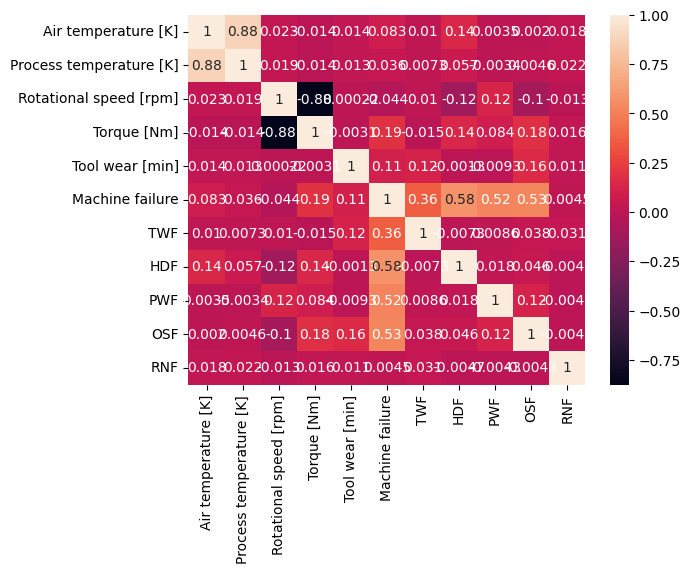

In [14]:
sns.heatmap(df.corr(method='pearson',numeric_only=True),annot=True)

In [15]:
corr = df.corr(numeric_only=True)

corr

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556,0.009955,0.137831,0.003470,0.001988,0.017688
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946,0.007315,0.056933,-0.003355,0.004554,0.022279
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188,0.010389,-0.121241,0.123018,-0.104575,-0.013088
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321,-0.014662,0.142610,0.083781,0.183465,0.016136
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448,0.115792,-0.001287,-0.009334,0.155894,0.011326
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000,0.362904,0.575800,0.522812,0.531083,0.004516
TWF,0.009955,0.007315,0.010389,-0.014662,0.115792,0.362904,1.000000,-0.007332,0.008577,0.038243,0.030970
HDF,0.137831,0.056933,-0.121241,0.142610,-0.001287,0.575800,-0.007332,1.000000,0.018443,0.046396,-0.004706
PWF,0.003470,-0.003355,0.123018,0.083781,-0.009334,0.522812,0.008577,0.018443,1.000000,0.115836,-0.004273
OSF,0.001988,0.004554,-0.104575,0.183465,0.155894,0.531083,0.038243,0.046396,0.115836,1.000000,-0.004341


In [16]:
corr = df.corr(numeric_only=True)
target_corr = corr["Machine failure"].sort_values(ascending=False)
target_corr

Machine failure            1.000000
HDF                        0.575800
OSF                        0.531083
PWF                        0.522812
TWF                        0.362904
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
RNF                        0.004516
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64

In [17]:
df=df.drop(columns=['TWF','HDF','PWF','OSF','RNF'])

In [18]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [19]:
from sklearn.preprocessing import LabelEncoder
l=LabelEncoder()
df['Type']=l.fit_transform(df['Type'])

In [20]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,2,298.1,308.6,1551,42.8,0,0
1,1,298.2,308.7,1408,46.3,3,0
2,1,298.1,308.5,1498,49.4,5,0
3,1,298.2,308.6,1433,39.5,7,0
4,1,298.2,308.7,1408,40.0,9,0


In [21]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
cols=['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Torque [Nm]','Tool wear [min]']
df[cols]=scalar.fit_transform(df[cols])

In [22]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,2,-0.952389,-0.947360,0.068185,0.282200,-1.695984,0
1,1,-0.902393,-0.879959,-0.729472,0.633308,-1.648852,0
2,1,-0.952389,-1.014761,-0.227450,0.944290,-1.617430,0
3,1,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009,0
4,1,-0.902393,-0.879959,-0.729472,0.001313,-1.554588,0
...,...,...,...,...,...,...,...
9995,2,-0.602417,-1.082162,0.363820,-1.052012,-1.476034,0
9996,0,-0.552421,-1.082162,0.520005,-0.821283,-1.428902,0
9997,2,-0.502425,-0.947360,0.592519,-0.660777,-1.350349,0
9998,0,-0.502425,-0.879959,-0.729472,0.854005,-1.303217,0


In [23]:
df['Type'].value_counts()

Type
1    6000
2    2997
0    1003
Name: count, dtype: int64

In [24]:
X=df.drop('Machine failure',axis=1)
y=df['Machine failure']

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [27]:
from sklearn.metrics import f1_score,accuracy_score,precision_score,recall_score,classification_report,confusion_matrix

In [28]:
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()
log_model.fit(X_train,y_train)
log_pred=log_model.predict(X_test)


In [29]:
log_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(3300,))

In [30]:
accuracy_score(y_test,log_pred)

0.9748484848484849

In [31]:
print(classification_report(y_test,log_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3199
           1       0.75      0.27      0.39       101

    accuracy                           0.97      3300
   macro avg       0.86      0.63      0.69      3300
weighted avg       0.97      0.97      0.97      3300



In [32]:
print(confusion_matrix(y_test,log_pred))

[[3190    9]
 [  74   27]]


In [33]:
train_accuracy = log_model.score(X_train, y_train)
test_accuracy = log_model.score(X_test, y_test)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9679104477611941
Testing Accuracy: 0.9748484848484849


In [34]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, log_pred)
print(cm)

[[3190    9]
 [  74   27]]


In [35]:
from sklearn.svm import SVC
svm_model=SVC()
svm_model.fit( X_train,y_train)
svm_pred=svm_model.predict(X_test)
svm_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(3300,))

In [36]:
print(confusion_matrix(y_test,svm_pred))

[[3197    2]
 [  76   25]]


In [37]:
print(classification_report(y_test,svm_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3199
           1       0.93      0.25      0.39       101

    accuracy                           0.98      3300
   macro avg       0.95      0.62      0.69      3300
weighted avg       0.98      0.98      0.97      3300



In [38]:
accuracy_score(y_test,svm_pred)

0.9763636363636363

In [39]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
print(classification_report(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3199
           1       0.69      0.68      0.69       101

    accuracy                           0.98      3300
   macro avg       0.84      0.84      0.84      3300
weighted avg       0.98      0.98      0.98      3300

[[3168   31]
 [  32   69]]


In [40]:
accuracy_score(y_test,dt_pred)

0.980909090909091

In [41]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

In [42]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      3199
           1       0.34      0.21      0.26       101

    accuracy                           0.96      3300
   macro avg       0.66      0.60      0.62      3300
weighted avg       0.96      0.96      0.96      3300



In [43]:
print(confusion_matrix(y_test, nb_pred))

[[3159   40]
 [  80   21]]


In [44]:
from sklearn.ensemble import RandomForestClassifier
random_model=RandomForestClassifier(n_estimators=120)
random_model.fit(X_train,y_train)
rf_pred = random_model.predict(X_test)


In [45]:
accuracy_score(y_test,rf_pred)

0.9875757575757576

In [46]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3199
           1       0.92      0.65      0.76       101

    accuracy                           0.99      3300
   macro avg       0.95      0.83      0.88      3300
weighted avg       0.99      0.99      0.99      3300



In [47]:
confusion_matrix(y_test,rf_pred)

array([[3193,    6],
       [  35,   66]])

In [48]:
print("Training accuracy:",random_model.score(X_train,y_train))
print("Test accuracy:",random_model.score(X_test,y_test))

Training accuracy: 1.0
Test accuracy: 0.9875757575757576


In [49]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

In [50]:
print("Training Accuracy:", gb_model.score(X_train, y_train))
print("Testing Accuracy:", gb_model.score(X_test, y_test))


Training Accuracy: 0.9913432835820896
Testing Accuracy: 0.9851515151515151


In [ ]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3199
           1       0.83      0.64      0.73       101

    accuracy                           0.99      3300
   macro avg       0.91      0.82      0.86      3300
weighted avg       0.98      0.99      0.98      3300



In [ ]:
print(confusion_matrix(y_test, gb_pred))

[[3186   13]
 [  36   65]]


In [ ]:
results = {
    "Model": [
        "Logistic Regression",
        "SVM",
        "Decision Tree",
        "Naive Bayes",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Training Accuracy": [
        log_model.score(X_train, y_train),
        svm_model.score(X_train, y_train),
        dt_model.score(X_train, y_train),
        nb_model.score(X_train, y_train),
        random_model.score(X_train, y_train),
        gb_model.score(X_train, y_train)
    ],

    "Testing Accuracy": [
        log_model.score(X_test, y_test),
        svm_model.score(X_test, y_test),
        dt_model.score(X_test, y_test),
        nb_model.score(X_test, y_test),
        random_model.score(X_test, y_test),
        gb_model.score(X_test, y_test)
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Training Accuracy,Testing Accuracy
0,Logistic Regression,0.967910,0.974848
1,SVM,0.971343,0.976364
2,Decision Tree,1.000000,0.980909
3,Naive Bayes,0.958209,0.963636
4,Random Forest,1.000000,0.987576
5,Gradient Boosting,0.991343,0.985152


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
# Parameters we want to try
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
# Random Forest
rf = RandomForestClassifier(random_state=42)
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)
# Best score
print("Best CV F1 Score:", grid_search.best_score_)

Best Parameters:
{'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1 Score: 0.6890391776377984


In [ ]:
best_rf = grid_search.best_estimator_

In [ ]:
rf_tuned_pred=best_rf.predict(X_test)

In [ ]:
print("Training Accuracy:", best_rf.score(X_train, y_train))
print("Testing Accuracy:", best_rf.score(X_test, y_test))

print("\nClassification Report:")
print(classification_report(y_test, rf_tuned_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_tuned_pred))

Training Accuracy: 0.9934328358208955
Testing Accuracy: 0.9860606060606061

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3199
           1       0.89      0.62      0.73       101

    accuracy                           0.99      3300
   macro avg       0.94      0.81      0.86      3300
weighted avg       0.99      0.99      0.98      3300


Confusion Matrix:
[[3191    8]
 [  38   63]]


In [58]:
import joblib

joblib.dump(best_rf, "model.pkl")


['model.pkl']

In [59]:
import joblib

joblib.dump(scalar, "scaler.pkl")

['scaler.pkl']